# Analiza danych i inżynieria cech

Przykład na zbiorze: https://www.kaggle.com/datasets/kiva/data-science-for-good-kiva-crowdfunding?select=kiva_loans.csv

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns

Załadowanie danych, na podstawie wstępnej analizy pliku z danymi: 
- separator pól CSV: ','
- separator dziesiętny: '.'
- kodowanie pliku: 'utf-8'

In [3]:
dane = pd.read_csv('kiva_loans.csv', sep=',', decimal='.', encoding='utf-8')

### Informacje o danych
Podstawowe informacje o załadowanych danych, wyświetlanie części danych (pierwsze 5 rekordów)

In [4]:
dane.info()
dane.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   use                 666973 non-null  object 
 6   country_code        671197 non-null  object 
 7   country             671205 non-null  object 
 8   region              614405 non-null  object 
 9   currency            671205 non-null  object 
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  object 
 12  disbursed_time      668809 non-null  object 
 13  funded_time         622874 non-null  object 
 14  term_in_months      671205 non-null  float64
 15  lender_count        671205 non-nul

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16,NaN,female,monthly,2014-01-01


### Analiza ilości rekordów w zależności od cechy 'country'
Wykres ilościowy (słupkowy) przedstawiający 5 krajów z największą ilością rekordów

country
Philippines    160441
Kenya           75825
El Salvador     39875
Cambodia        34836
Pakistan        26857


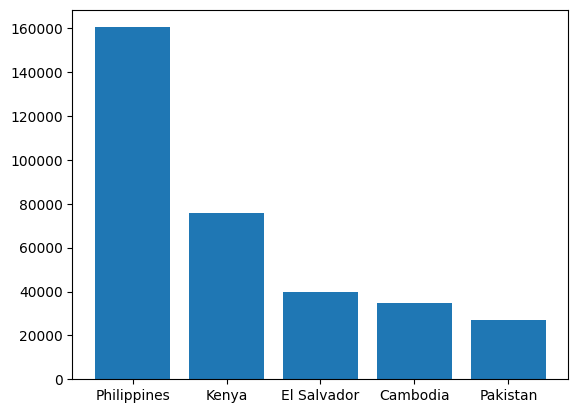

In [45]:
df = dane['country'].value_counts().head()
print(df.to_string())
plt.bar(df.index,df.values);

### Informacje o konkretnym kraju np. o Filipinach

In [6]:
Phil = dane[dane['country'] == 'Philippines'].copy().reset_index()
Phil.head()

,index,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,...,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,51,653092,175.0,175.0,Pigs,Agriculture,to buy piglets and feed,PH,Philippines,Liloy-Dela Paz,...,126.0,2014-01-02 00:25:40+00:00,2013-12-12 08:00:00+00:00,2014-01-02 01:42:51+00:00,8.0,6,NaN,female,irregular,2014-01-02
1,52,653149,175.0,175.0,Pigs,Agriculture,to purchase feed and vitamins for her pigs,PH,Philippines,"Tanjay, Negros Oriental",...,145.0,2014-01-02 04:18:30+00:00,2013-12-06 08:00:00+00:00,2014-01-02 07:47:28+00:00,8.0,7,NaN,female,irregular,2014-01-02
2,55,653123,700.0,700.0,General Store,Retail,"to buy additional items like eggs, charcoal, r...",PH,Philippines,"Brookes Point, Palawan",...,145.0,2014-01-02 02:18:02+00:00,2013-12-10 08:00:00+00:00,2014-01-02 03:26:10+00:00,5.0,2,NaN,female,irregular,2014-01-02
3,56,653338,575.0,575.0,Farming,Agriculture,to purchase fertilizers and other farm supplies,PH,Philippines,"Tanjay, Negros Oriental",...,145.0,2014-01-02 13:38:42+00:00,2013-12-05 08:00:00+00:00,2014-01-02 23:01:23+00:00,8.0,19,NaN,female,irregular,2014-01-02
4,65,653242,325.0,325.0,General Store,Retail,"to purchase sugar, coffee, coffee creamer, can...",PH,Philippines,"Sinippil, Cauayan City, Isabela",...,123.0,2014-01-02 09:13:05+00:00,2013-12-13 08:00:00+00:00,2014-01-02 17:50:06+00:00,7.0,11,volunteer_pick,female,irregular,2014-01-02


In [7]:
Phil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160441 entries, 0 to 160440
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               160441 non-null  int64  
 1   id                  160441 non-null  int64  
 2   funded_amount       160441 non-null  float64
 3   loan_amount         160441 non-null  float64
 4   activity            160441 non-null  object 
 5   sector              160441 non-null  object 
 6   use                 160361 non-null  object 
 7   country_code        160441 non-null  object 
 8   country             160441 non-null  object 
 9   region              160360 non-null  object 
 10  currency            160441 non-null  object 
 11  partner_id          160441 non-null  float64
 12  posted_time         160441 non-null  object 
 13  disbursed_time      160441 non-null  object 
 14  funded_time         157607 non-null  object 
 15  term_in_months      160441 non-nul

In [8]:
Phil.isnull().sum()

index                     0
id                        0
funded_amount             0
loan_amount               0
activity                  0
sector                    0
use                      80
country_code              0
country                   0
region                   81
currency                  0
partner_id                0
posted_time               0
disbursed_time            0
funded_time            2834
term_in_months            0
lender_count              0
tags                  66347
borrower_genders         80
repayment_interval        0
date                      0
dtype: int64

### Uzupełnianie brakujących danych
tags - wartość tekstowa


In [9]:
Phil['tags'].value_counts()

tags
#Parent, #Woman Owned Biz                                                                                                      7204
user_favorite                                                                                                                  5953
#Woman Owned Biz                                                                                                               4911
#Elderly                                                                                                                       2756
#Parent, #Repeat Borrower, #Woman Owned Biz                                                                                    2269
                                                                                                                               ... 
#Animals, #Repeat Borrower, #Parent, #Woman Owned Biz, #Animals, #Parent, #Woman Owned Biz, #Repeat Borrower, user_favorite       1
#Repeat Borrower, #Elderly, #Single, #Woman Owned Biz, #Woman Owned Biz

Wybór najczęściej występującego tagu

In [10]:
dominata = Phil['tags'].mode()
print("Dominująca kategoria:", dominata[0]) 

Dominująca kategoria: #Parent, #Woman Owned Biz


Uzupełnienie brakujących danych najpopulrniejszą wartością

In [11]:
# Phil['tags'].fillna(dominata[0],inplace=True)
Phil.fillna({'tags': dominata[0]}, inplace=True)
Phil.head()

,index,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,...,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,51,653092,175.0,175.0,Pigs,Agriculture,to buy piglets and feed,PH,Philippines,Liloy-Dela Paz,...,126.0,2014-01-02 00:25:40+00:00,2013-12-12 08:00:00+00:00,2014-01-02 01:42:51+00:00,8.0,6,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
1,52,653149,175.0,175.0,Pigs,Agriculture,to purchase feed and vitamins for her pigs,PH,Philippines,"Tanjay, Negros Oriental",...,145.0,2014-01-02 04:18:30+00:00,2013-12-06 08:00:00+00:00,2014-01-02 07:47:28+00:00,8.0,7,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
2,55,653123,700.0,700.0,General Store,Retail,"to buy additional items like eggs, charcoal, r...",PH,Philippines,"Brookes Point, Palawan",...,145.0,2014-01-02 02:18:02+00:00,2013-12-10 08:00:00+00:00,2014-01-02 03:26:10+00:00,5.0,2,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
3,56,653338,575.0,575.0,Farming,Agriculture,to purchase fertilizers and other farm supplies,PH,Philippines,"Tanjay, Negros Oriental",...,145.0,2014-01-02 13:38:42+00:00,2013-12-05 08:00:00+00:00,2014-01-02 23:01:23+00:00,8.0,19,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
4,65,653242,325.0,325.0,General Store,Retail,"to purchase sugar, coffee, coffee creamer, can...",PH,Philippines,"Sinippil, Cauayan City, Isabela",...,123.0,2014-01-02 09:13:05+00:00,2013-12-13 08:00:00+00:00,2014-01-02 17:50:06+00:00,7.0,11,volunteer_pick,female,irregular,2014-01-02


Ponowna kontrola ilości wartości pustych w poszczególnych kolumnach

In [12]:
Phil.isnull().sum()

index                    0
id                       0
funded_amount            0
loan_amount              0
activity                 0
sector                   0
use                     80
country_code             0
country                  0
region                  81
currency                 0
partner_id               0
posted_time              0
disbursed_time           0
funded_time           2834
term_in_months           0
lender_count             0
tags                     0
borrower_genders        80
repayment_interval       0
date                     0
dtype: int64

## Kodowanie etykiety na liczby
- Kodowanie etykiety (Label Encoding)
- Kodowanie 1 z n (One-Hot Encoding)
- Kodowanie zmiennej fikcyjnej (Dummy Encoding)

Przykład zamieniający wartości w kolumnie region na etykiety liczbowe

In [ ]:
# labEnc = preprocessing.LabelEncoder()
# Phil['region'] = labEnc.fit_transform(Phil['region'])
# # Phil['region'].unique()
# Phil.isnull().sum() 

labEnc = preprocessing.LabelEncoder()

not_null_mask = Phil['region'].notnull()
Phil.loc[not_null_mask, 'region'] = labEnc.fit_transform(Phil.loc[not_null_mask, 'region'])
Phil.isnull().sum() 

index                    0
id                       0
funded_amount            0
loan_amount              0
activity                 0
sector                   0
use                     80
country_code             0
country                  0
region                  81
currency                 0
partner_id               0
posted_time              0
disbursed_time           0
funded_time           2834
term_in_months           0
lender_count             0
tags                     0
borrower_genders        80
repayment_interval       0
date                     0
dtype: int64

In [14]:
Phil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160441 entries, 0 to 160440
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               160441 non-null  int64  
 1   id                  160441 non-null  int64  
 2   funded_amount       160441 non-null  float64
 3   loan_amount         160441 non-null  float64
 4   activity            160441 non-null  object 
 5   sector              160441 non-null  object 
 6   use                 160361 non-null  object 
 7   country_code        160441 non-null  object 
 8   country             160441 non-null  object 
 9   region              160360 non-null  object 
 10  currency            160441 non-null  object 
 11  partner_id          160441 non-null  float64
 12  posted_time         160441 non-null  object 
 13  disbursed_time      160441 non-null  object 
 14  funded_time         157607 non-null  object 
 15  term_in_months      160441 non-nul

<Axes: xlabel='region', ylabel='Count'>

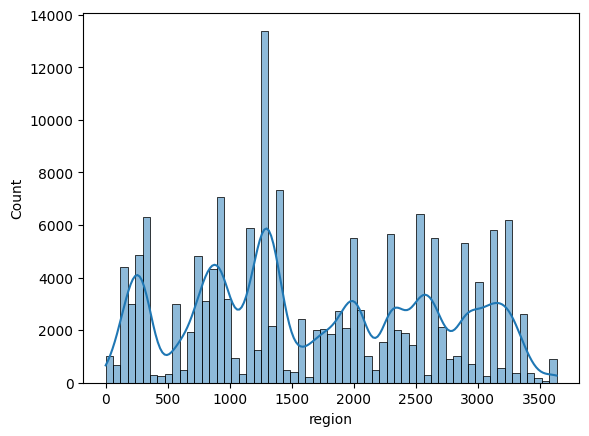

In [15]:
sns.histplot(Phil['region'], kde=True)

In [41]:
mediana = Phil['region'].median()
print("Mediana regionu:", mediana)
# Phil['region'].fillna(mediana, inplace=True)
Phil.fillna({'region': mediana}, inplace=True)
Phil['region'] = Phil['region'].astype('int64')

Mediana regionu: 1421.0


In [17]:
Phil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160441 entries, 0 to 160440
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               160441 non-null  int64  
 1   id                  160441 non-null  int64  
 2   funded_amount       160441 non-null  float64
 3   loan_amount         160441 non-null  float64
 4   activity            160441 non-null  object 
 5   sector              160441 non-null  object 
 6   use                 160361 non-null  object 
 7   country_code        160441 non-null  object 
 8   country             160441 non-null  object 
 9   region              160441 non-null  int64  
 10  currency            160441 non-null  object 
 11  partner_id          160441 non-null  float64
 12  posted_time         160441 non-null  object 
 13  disbursed_time      160441 non-null  object 
 14  funded_time         157607 non-null  object 
 15  term_in_months      160441 non-nul

## Usuwanie zbędnych cech (kolumn)
Dla przykładu uznamy, że kolumny: country_code, tags i date, nie są nam do niczego potrzebne, więc je usunimey z danych:

In [18]:
Phil.drop(['id','country_code','tags','date'], axis=1, inplace=True)

In [19]:
Phil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160441 entries, 0 to 160440
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               160441 non-null  int64  
 1   funded_amount       160441 non-null  float64
 2   loan_amount         160441 non-null  float64
 3   activity            160441 non-null  object 
 4   sector              160441 non-null  object 
 5   use                 160361 non-null  object 
 6   country             160441 non-null  object 
 7   region              160441 non-null  int64  
 8   currency            160441 non-null  object 
 9   partner_id          160441 non-null  float64
 10  posted_time         160441 non-null  object 
 11  disbursed_time      160441 non-null  object 
 12  funded_time         157607 non-null  object 
 13  term_in_months      160441 non-null  float64
 14  lender_count        160441 non-null  int64  
 15  borrower_genders    160361 non-nul

Analiza danych wyłącznie typu liczbowego (int, float)

In [20]:
daneNum = Phil.select_dtypes(include=['int64', 'float64'])
daneNum.head()

,index,funded_amount,loan_amount,region,partner_id,term_in_months,lender_count
0,51,175.0,175.0,1608,126.0,8.0,6
1,52,175.0,175.0,3225,145.0,8.0,7
2,55,700.0,700.0,583,145.0,5.0,2
3,56,575.0,575.0,3225,145.0,8.0,19
4,65,325.0,325.0,2999,123.0,7.0,11


In [21]:
daneNum.corr()

,index,funded_amount,loan_amount,region,partner_id,term_in_months,lender_count
index,1.000000,-0.071412,-0.066755,-0.008379,0.030266,-0.086293,-0.248229
funded_amount,-0.071412,1.000000,0.976438,-0.018409,0.045311,0.079585,0.763405
loan_amount,-0.066755,0.976438,1.000000,-0.017603,0.035690,0.105319,0.747766
region,-0.008379,-0.018409,-0.017603,1.000000,-0.026921,-0.008519,-0.024185
partner_id,0.030266,0.045311,0.035690,-0.026921,1.000000,-0.052731,0.000424
term_in_months,-0.086293,0.079585,0.105319,-0.008519,-0.052731,1.000000,0.196910
lender_count,-0.248229,0.763405,0.747766,-0.024185,0.000424,0.196910,1.000000


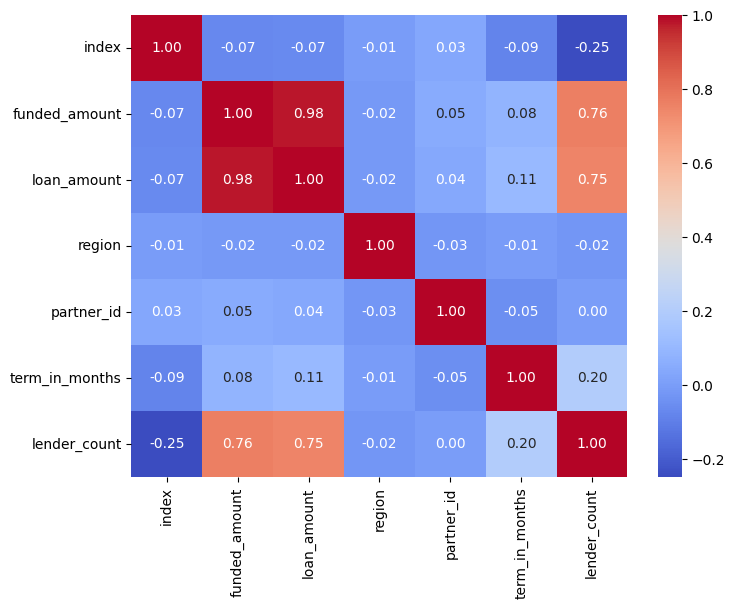

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(daneNum.corr(), annot=True, cmap='coolwarm', fmt='.2f');

### Grupowanie danych

In [38]:
loan_by_sector = Phil.groupby('sector')['loan_amount'].sum().sort_values(ascending=False).reset_index().head()

loan_by_sector

,sector,loan_amount
0,Retail,19240475.0
1,Food,14757800.0
2,Agriculture,11926025.0
3,Housing,1884600.0
4,Services,1838575.0


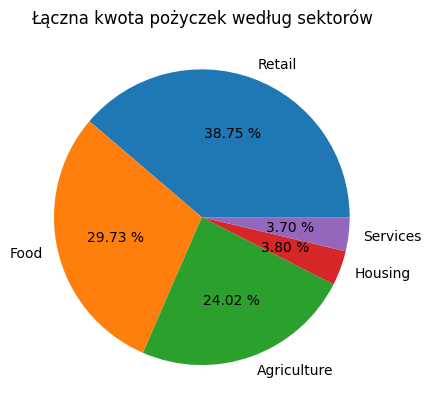

In [39]:
def value_format(x):
    return f"{x:,.2f} %"

plt.pie(loan_by_sector['loan_amount'], labels=loan_by_sector['sector'], autopct=value_format)
plt.title('Łączna kwota pożyczek według sektorów')
plt.show()


### Wartości odstające

Prezentacja danych za pomocą wykresów pudełkowych

In [36]:
Phil.describe() 

,index,funded_amount,loan_amount,region,partner_id,term_in_months,lender_count
count,160441.000000,160441.000000,160441.000000,160441.000000,160441.000000,160441.000000,160441.000000
mean,344758.371270,339.541483,344.938170,1686.484483,141.213642,9.881969,8.592398
std,189566.770455,229.939313,234.917842,969.127256,19.449993,5.398081,7.243188
min,51.000000,0.000000,25.000000,0.000000,123.000000,2.000000,0.000000
25%,188503.000000,225.000000,225.000000,925.000000,136.000000,8.000000,4.000000
50%,344368.000000,275.000000,275.000000,1421.000000,145.000000,8.000000,7.000000
75%,503529.000000,425.000000,425.000000,2556.000000,145.000000,11.000000,11.000000
max,670445.000000,25000.000000,25000.000000,3637.000000,508.000000,97.000000,747.000000


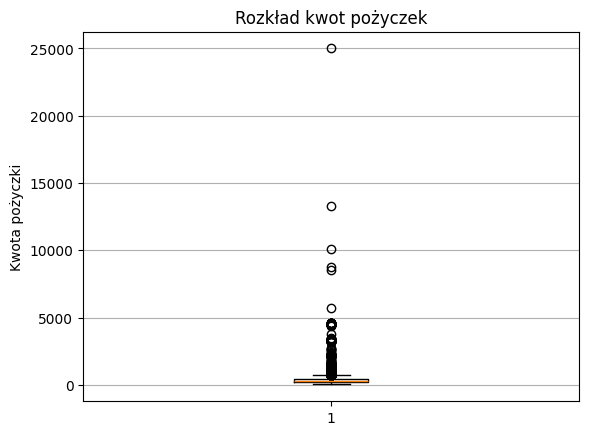

In [27]:
plt.boxplot(Phil['loan_amount'])
plt.title('Rozkład kwot pożyczek')
plt.ylabel('Kwota pożyczki')   

plt.grid(axis='y') 

plt.show()


Usuwanie wartości odstających

In [35]:
maxQ = Phil['loan_amount'].quantile(0.8)
minQ = Phil['loan_amount'].quantile(0.15)
print("20. percentyl kwoty pożyczki:", minQ)
print("80. percentyl kwoty pożyczki:", maxQ)

modPhil = Phil[(Phil['loan_amount'] >= minQ) & (Phil['loan_amount'] <= maxQ)].copy()
modPhil.describe()

20. percentyl kwoty pożyczki: 175.0
80. percentyl kwoty pożyczki: 450.0


,index,funded_amount,loan_amount,region,partner_id,term_in_months,lender_count
count,108169.000000,108169.000000,108169.000000,108169.000000,108169.000000,108169.000000,108169.000000
mean,346727.486082,289.015106,291.130546,1668.401335,141.897901,9.927863,7.526556
std,189039.311203,81.050224,80.306470,965.322304,17.334065,5.484164,4.104336
min,51.000000,0.000000,175.000000,2.000000,123.000000,2.000000,0.000000
25%,191256.000000,225.000000,225.000000,925.000000,144.000000,8.000000,5.000000
50%,346330.000000,275.000000,275.000000,1419.000000,145.000000,8.000000,8.000000
75%,504639.000000,350.000000,350.000000,2523.000000,145.000000,11.000000,10.000000
max,670436.000000,450.000000,450.000000,3637.000000,409.000000,62.000000,18.000000


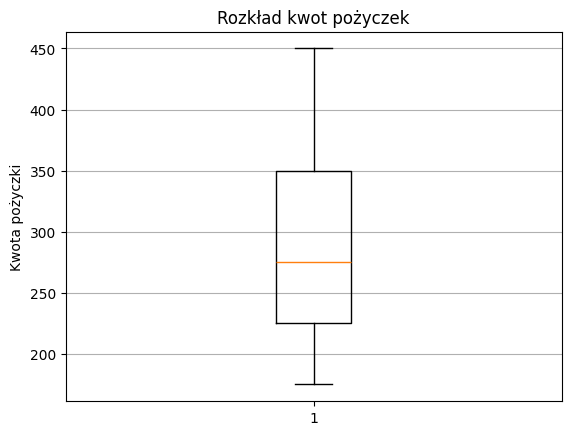

In [34]:
plt.boxplot(modPhil['loan_amount'])
plt.title('Rozkład kwot pożyczek')
plt.ylabel('Kwota pożyczki')   

plt.grid(axis='y') 

plt.show()